# Arctic Grid Spectral Analysis — CRISTAL Sea Ice Thickness (CIT)

This notebook performs spectral analysis of **Sea Ice Thickness (SIT)** predictions from CRISTAL-like data at two resolutions:
- **x50** — 25 km resolution (full period, Feb 1–15)
- **x10** — 5 km resolution (Feb 8–15)

Both files contain:
- `pred_SIT`: 4DVarNet reconstruction/forecast
- `models_SIT`: model reference (used as ground truth)

The **last 3 time steps** are forecast lead times (lead-0, lead-1, lead-2).  
Spectral evaluation is performed:
1. Over the **analysis period** (non-forecast days) for each resolution.
2. Per **lead time** (0, 1, 2), comparing: Reference (`models_SIT`), Persistence (last analysis day of `models_SIT`), and Forecast (`pred_SIT`), for both resolutions.


In [1]:
import numpy as np
import xarray as xr
import scipy.signal
from skimage.draw import line
import matplotlib.pyplot as plt
import logging

logger = logging.getLogger()
logger.setLevel(logging.INFO)

In [2]:
# ── Load CRISTAL CIT data at two resolutions ──────────────────────────────────
import numpy as np
import xarray as xr
import os

print("=" * 80)
print("LOADING CRISTAL SEA ICE THICKNESS (CIT) DATA")
print("=" * 80)

FILE_X50 = '/data/users/maxb/NetCDF_tests/test_data_20210201_20210215_patch_x50.nc'
FILE_X10 = '/data/users/maxb/NetCDF_tests/test_data_20210208_20210215_patch_x10.nc'

N_FORECAST = 3   # last 3 time steps are forecast (lead-0, lead-1, lead-2)

cristal_data = {}   # keyed by 'x50' and 'x10'

for key, fpath in [('x50', FILE_X50), ('x10', FILE_X10)]:
    print(f"\n{'─'*60}")
    print(f"Loading {key} — {os.path.basename(fpath)}")
    ds = xr.open_dataset(fpath)

    xc = ds.xc.values   # metres
    yc = ds.yc.values
    dx = abs(np.mean(np.diff(xc))) / 1000.0   # km
    dy = abs(np.mean(np.diff(yc))) / 1000.0

    nt = ds.dims['time']
    n_analysis = nt - N_FORECAST

    pred_all   = ds['pred_SIT'].values    # (time, yc, xc)
    models_all = ds['models_SIT'].values  # (time, yc, xc)
    times      = ds.time.values

    # Split analysis vs forecast
    pred_analysis   = pred_all[:n_analysis]
    models_analysis = models_all[:n_analysis]

    pred_forecast   = pred_all[n_analysis:]          # (3, yc, xc)
    models_forecast = models_all[n_analysis:]        # (3, yc, xc)  ← reference
    persistence     = models_all[[n_analysis - 1] * N_FORECAST]  # repeat last analysis day

    cristal_data[key] = {
        'xc': xc, 'yc': yc, 'dx': dx, 'dy': dy,
        'resolution_km': dx,
        'times_all': times,
        'times_analysis': times[:n_analysis],
        'times_forecast': times[n_analysis:],
        # Analysis arrays  (time, yc, xc)
        'pred_analysis':   pred_analysis,
        'models_analysis': models_analysis,
        # Forecast arrays  (3, yc, xc) — one per lead time
        'pred_forecast':   pred_forecast,
        'models_forecast': models_forecast,
        'persistence':     persistence,
    }

    print(f"  Grid          : {len(xc)} × {len(yc)},  dx = {dx:.1f} km")
    print(f"  Total time    : {nt} days  ({times[0].astype('datetime64[D]')} → {times[-1].astype('datetime64[D]')})")
    print(f"  Analysis days : {n_analysis}  ({times[0].astype('datetime64[D]')} → {times[n_analysis-1].astype('datetime64[D]')})")
    print(f"  Forecast days : {N_FORECAST}  (lead-0={times[n_analysis].astype('datetime64[D]')}, "
          f"lead-1={times[n_analysis+1].astype('datetime64[D]')}, lead-2={times[n_analysis+2].astype('datetime64[D]')})")
    print(f"  pred_SIT      : range=[{np.nanmin(pred_all):.3f}, {np.nanmax(pred_all):.3f}]  "
          f"NaN%={100*np.isnan(pred_all).mean():.1f}%")
    print(f"  models_SIT    : range=[{np.nanmin(models_all):.3f}, {np.nanmax(models_all):.3f}]  "
          f"NaN%={100*np.isnan(models_all).mean():.1f}%")
    ds.close()

print(f"\n{'='*80}")
print("✓ ALL DATA LOADED")
print("=" * 80)


LOADING CRISTAL SEA ICE THICKNESS (CIT) DATA

────────────────────────────────────────────────────────────
Loading x50 — test_data_20210201_20210215_patch_x50.nc


/tmp/ipykernel_2676176/3097745838.py:27: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  nt = ds.dims['time']


  Grid          : 304 × 294,  dx = 25.0 km
  Total time    : 15 days  (2021-02-01 → 2021-02-15)
  Analysis days : 12  (2021-02-01 → 2021-02-12)
  Forecast days : 3  (lead-0=2021-02-13, lead-1=2021-02-14, lead-2=2021-02-15)
  pred_SIT      : range=[-0.287, 14.958]  NaN%=57.8%
  models_SIT    : range=[0.000, 14.259]  NaN%=57.8%

────────────────────────────────────────────────────────────
Loading x10 — test_data_20210208_20210215_patch_x10.nc


/tmp/ipykernel_2676176/3097745838.py:27: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  nt = ds.dims['time']


  Grid          : 1520 × 1474,  dx = 5.0 km
  Total time    : 8 days  (2021-02-08 → 2021-02-15)
  Analysis days : 5  (2021-02-08 → 2021-02-12)
  Forecast days : 3  (lead-0=2021-02-13, lead-1=2021-02-14, lead-2=2021-02-15)
  pred_SIT      : range=[-0.545, 5.203]  NaN%=60.8%
  models_SIT    : range=[0.000, 5.014]  NaN%=60.8%

✓ ALL DATA LOADED
  models_SIT    : range=[0.000, 5.014]  NaN%=60.8%

✓ ALL DATA LOADED


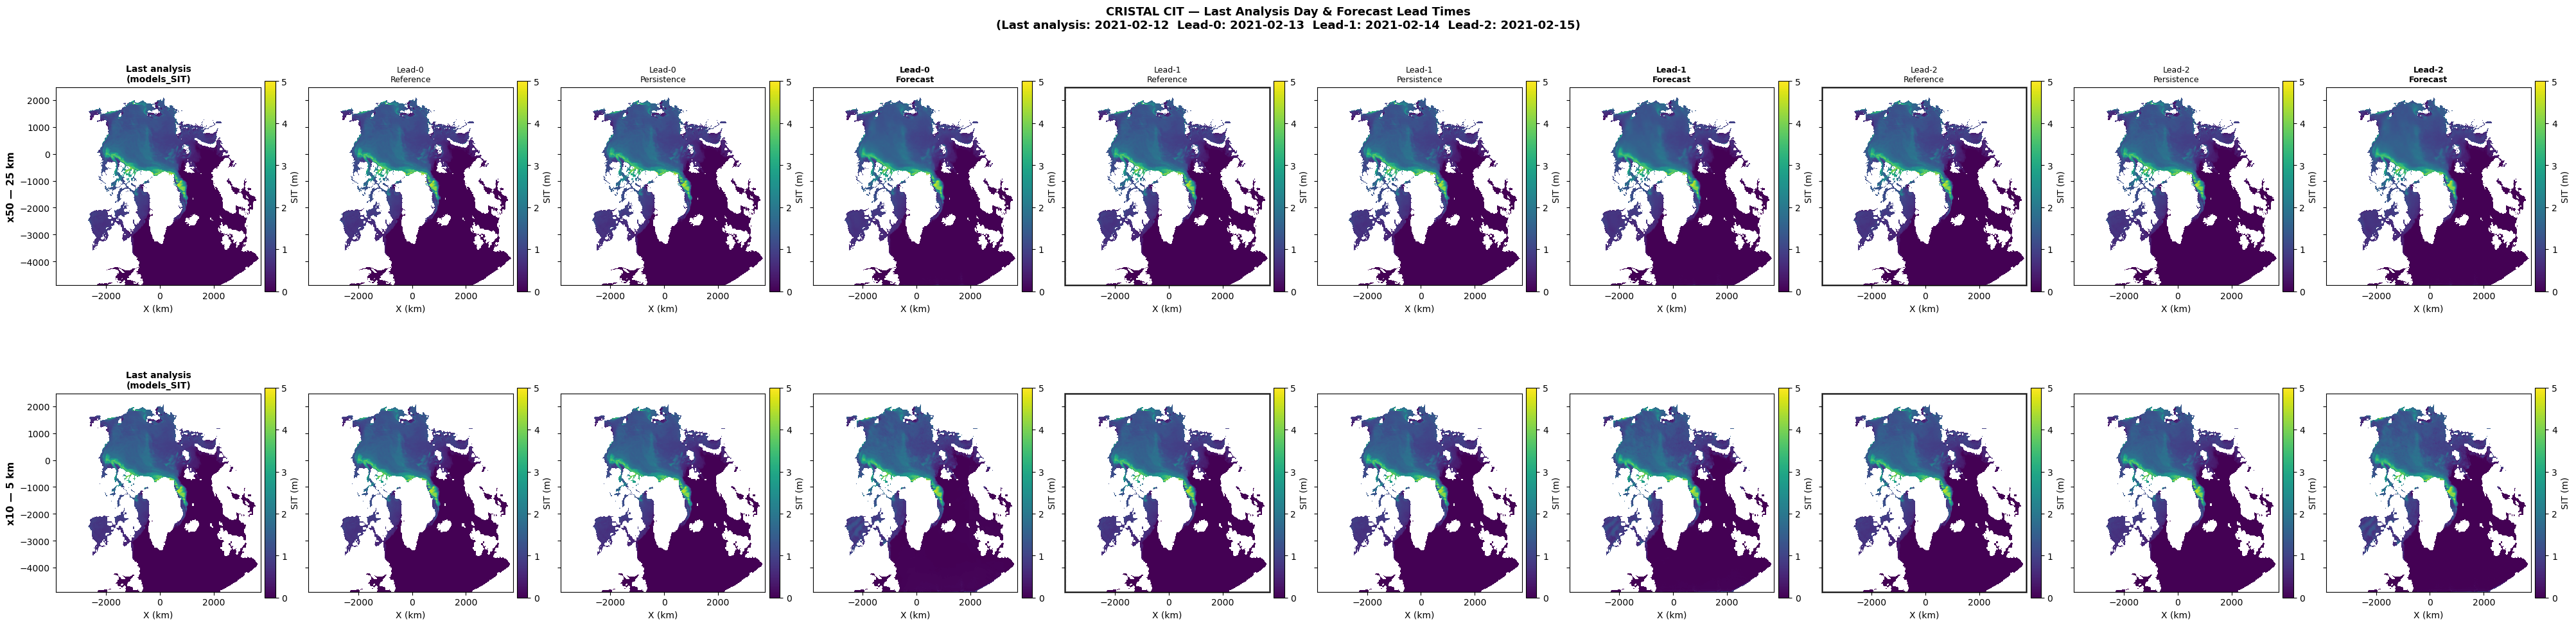


✓ Overview map saved to /data/users/maxb/cristal_cit_overview.png


In [3]:
# ── Quick-look maps: last analysis day + 3 forecast lead times ────────────────
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

CMAP = 'viridis'
VMIN, VMAX = 0.0, 5.0

def km(arr):
    """Return coordinate array in km (divide if in metres)."""
    return arr / 1000.0 if np.nanmax(np.abs(arr)) > 10_000 else arr

n_rows = 2              # one row per resolution
n_cols = 1 + 2 + N_FORECAST   # last-analysis | [ref, persist, forecast] × 3 lead times → 8 cols total
# Layout: [last analysis | lead-0 ref | lead-0 persist | lead-0 forecast | lead-1 … | lead-2 …]
# Simpler: 1+N_FORECAST*3 = 10 — let's do 2 rows × 7 cols (last_analysis + 3×(ref,pred))

ncols = 1 + N_FORECAST * 3
fig, axes = plt.subplots(n_rows, ncols, figsize=(4 * ncols, 5 * n_rows),
                         constrained_layout=True)

col_titles = ['Last analysis\n(models_SIT)']
for lt in range(N_FORECAST):
    col_titles += [f'Lead-{lt}\nReference', f'Lead-{lt}\nPersistence', f'Lead-{lt}\nForecast (pred)']

row_labels = ['x50 — 25 km', 'x10 — 5 km']

for r, key in enumerate(['x50', 'x10']):
    d = cristal_data[key]
    xc_km = km(d['xc'])
    yc_km = km(d['yc'])
    X, Y  = np.meshgrid(xc_km, yc_km, indexing='xy')

    # col 0: last analysis day
    ax = axes[r, 0]
    im = ax.pcolormesh(X, Y, d['models_analysis'][-1], cmap=CMAP,
                       vmin=VMIN, vmax=VMAX, shading='nearest', rasterized=True)
    ax.set_aspect('equal'); ax.set_xlabel('X (km)'); ax.set_ylabel('Y (km)')
    ax.set_title(col_titles[0], fontsize=10, fontweight='bold')
    if r == 0:
        ax.set_ylabel(row_labels[r], fontsize=11, fontweight='bold')
    else:
        ax.set_ylabel(row_labels[r], fontsize=11, fontweight='bold')
    plt.colorbar(im, ax=ax, label='SIT (m)', shrink=0.7, pad=0.02)

    # cols 1..9: lead times
    col = 1
    for lt in range(N_FORECAST):
        for field, label, arr in [
            ('ref',   f'Lead-{lt}\nReference',    d['models_forecast'][lt]),
            ('pers',  f'Lead-{lt}\nPersistence',  d['persistence'][lt]),
            ('pred',  f'Lead-{lt}\nForecast',     d['pred_forecast'][lt]),
        ]:
            ax = axes[r, col]
            im = ax.pcolormesh(X, Y, arr, cmap=CMAP, vmin=VMIN, vmax=VMAX,
                               shading='nearest', rasterized=True)
            ax.set_aspect('equal'); ax.set_xlabel('X (km)')
            ax.set_yticklabels([])
            ax.set_title(label if r == 0 else '', fontsize=9,
                         fontweight='bold' if field == 'pred' else 'normal')
            # vertical dashed line between lead groups
            if col in [1, 4, 7] and col > 1:
                for ax2 in axes[:, col]:
                    ax2.axvline(xc_km[0], color='gray', lw=1, ls='--', alpha=0.5)
            plt.colorbar(im, ax=ax, label='SIT (m)', shrink=0.7, pad=0.02)
            col += 1

# Add separators between lead-time groups
for c in [4, 7]:
    for r2 in range(n_rows):
        axes[r2, c].patch.set_edgecolor('dimgray')
        axes[r2, c].patch.set_linewidth(2)

fig.suptitle('CRISTAL CIT — Last Analysis Day & Forecast Lead Times\n'
             f'(Last analysis: {cristal_data["x50"]["times_analysis"][-1].astype("datetime64[D]")}  '
             f'Lead-0: {cristal_data["x50"]["times_forecast"][0].astype("datetime64[D]")}  '
             f'Lead-1: {cristal_data["x50"]["times_forecast"][1].astype("datetime64[D]")}  '
             f'Lead-2: {cristal_data["x50"]["times_forecast"][2].astype("datetime64[D]")})',
             fontsize=13, fontweight='bold')

out_map = '/data/users/maxb/cristal_cit_overview.png'
plt.savefig(out_map, dpi=120, bbox_inches='tight')
plt.show()
print(f"\n✓ Overview map saved to {out_map}")


## 1. Segments Class for Cartesian Coordinates

`SegmentsCartesian` generates random transects on a regular x/y (polar stereographic) grid using Euclidean geometry and Bresenham's line algorithm.


In [4]:
class SegmentsCartesian:
    """
    Segments class adapted for Cartesian x/y coordinate systems.
    Designed for Arctic grids with regular spacing in x/y (e.g., polar stereographic).
    
    Parameters
    ----------
    num_segments : int
        Number of random segments to generate
    min_dist : float
        Minimum segment length in kilometers
    max_dist : float
        Maximum segment length in kilometers
    overlapping : float
        Overlap fraction between segments (0-1)
    dx : float
        Grid spacing in x-direction (kilometers)
    dy : float
        Grid spacing in y-direction (kilometers)
    """
    
    def __init__(self, num_segments=1000, min_dist=200, max_dist=1000, 
                 overlapping=0.25, dx=2.2, dy=2.2):
        self.num_segments = num_segments
        self.min_dist = min_dist
        self.max_dist = max_dist
        self.overlapping = overlapping
        self.dx = dx  # Grid spacing in km
        self.dy = dy  # Grid spacing in km
        
    def find_point_cartesian(self, point_idx, angle, dist_km):
        """
        Find endpoint in Cartesian coordinates.
        
        Parameters
        ----------
        point_idx : tuple
            Starting point as (x_idx, y_idx) grid indices
        angle : float
            Angle in degrees (0° = East, 90° = North)
        dist_km : float
            Distance in kilometers
            
        Returns
        -------
        tuple
            Endpoint as (x_idx, y_idx) grid indices
        """
        x_idx, y_idx = point_idx
        angle_rad = np.radians(angle)
        
        # Convert distance to grid indices
        dx_cells = (dist_km * np.cos(angle_rad)) / self.dx
        dy_cells = (dist_km * np.sin(angle_rad)) / self.dy
        
        x_end = int(x_idx + dx_cells)
        y_end = int(y_idx + dy_cells)
        
        return x_end, y_end
    
    def get_idx_pt_endline(self, x1, y1, theta, distance_km):
        """
        Get endpoint indices for a line segment.
        
        Parameters
        ----------
        x1, y1 : int
            Starting grid indices
        theta : float
            Angle in degrees
        distance_km : float
            Distance in kilometers
            
        Returns
        -------
        tuple
            (x2, y2) endpoint grid indices
        """
        return self.find_point_cartesian((x1, y1), theta, distance_km)
    
    def compute_spatial_segment(self, time, x, y, obs, rec):
        """
        Compute spatial segments on Cartesian grid.
        
        Parameters
        ----------
        time : array
            Time coordinates
        x : array
            X-coordinates (1D array, can be in any units)
        y : array
            Y-coordinates (1D array, can be in any units)
        obs : array
            Observation data (time, y, x)
        rec : array
            Reconstruction data (time, y, x)
            
        Returns
        -------
        tuple
            (time_segments, x_segments, y_segments, obs_segments, rec_segments)
        """
        Nx = len(x)
        Ny = len(y)
        mesh_x, mesh_y = np.meshgrid(x, y)
        mesh_x = mesh_x.T
        mesh_y = mesh_y.T
        Nt = len(time)
        
        time_segments = []
        x_segments = []
        y_segments = []
        obs_segments = []
        rec_segments = []
        
        n_segments = 0
        while n_segments < self.num_segments:
            # Generate random starting points
            start_x = np.random.randint(Nx, size=1000)
            start_y = np.random.randint(Ny, size=1000)
            theta = np.random.randint(360, size=1000)
            distance = np.random.randint(self.min_dist, self.max_dist + 100, size=1000)
            
            # Calculate endpoints
            x2_y2 = [self.get_idx_pt_endline(x1, y1, angle, dist) 
                     for x1, y1, angle, dist in zip(start_x, start_y, theta, distance)]
            end_x = [xy[0] for xy in x2_y2]
            end_y = [xy[1] for xy in x2_y2]
            
            # Generate overlapping segments
            ovlp_distance = distance * (1 - self.overlapping)
            ovlp_start_x_start_y = [self.get_idx_pt_endline(x1, y1, angle, dist) 
                                    for x1, y1, angle, dist in 
                                    zip(start_x, start_y, theta, ovlp_distance)]
            ovlp_start_x = [xy[0] for xy in ovlp_start_x_start_y if xy[0] < Nx]
            ovlp_start_y = [xy[1] for xy in ovlp_start_x_start_y if xy[1] < Ny]
            
            ovlp_end_x_end_y = [self.get_idx_pt_endline(x1, y1, angle, dist) 
                                for x1, y1, angle, dist in 
                                zip(ovlp_start_x, ovlp_start_y, theta, distance)]
            ovlp_end_x = [xy[0] for xy in ovlp_end_x_end_y]
            ovlp_end_y = [xy[1] for xy in ovlp_end_x_end_y]
            
            # Concatenate candidates
            start_x = np.concatenate((start_x, ovlp_start_x))
            start_y = np.concatenate((start_y, ovlp_start_y))
            end_x = np.concatenate((end_x, ovlp_end_x))
            end_y = np.concatenate((end_y, ovlp_end_y))
            
            # Generate line coordinates
            line_in_img = zip(start_x, start_y, end_x, end_y)
            rr_cc = [line(*l) for l in line_in_img]
            rr = [c[0] for c in rr_cc]
            cc = [c[1] for c in rr_cc]
            
            # Random time selection
            tt = np.random.randint(Nt, size=len(cc))
            
            # Filter valid segments - check ALL points are in bounds
            def is_valid_segment(r, c):
                """Check if all points in segment are within bounds"""
                return (np.all(r >= 0) and np.all(r < Nx) and 
                       np.all(c >= 0) and np.all(c < Ny))
            
            valid_mask = [is_valid_segment(r, c) for r, c in zip(rr, cc)]
            
            time_segment = [t for t, valid in zip(tt, valid_mask) if valid]
            x_segment = [mesh_x[r, c] for r, c, valid in zip(rr, cc, valid_mask) if valid]
            y_segment = [mesh_y[r, c] for r, c, valid in zip(rr, cc, valid_mask) if valid]
            obs_segment = [obs[t, c, r] for t, r, c, valid in zip(tt, rr, cc, valid_mask) if valid]
            rec_segment = [rec[t, c, r] for t, r, c, valid in zip(tt, rr, cc, valid_mask) if valid]
            
            if len(obs_segment) > 0:
                # Check for NaN values
                ratio_nan_obs = [100 * (1 - np.mean(np.isfinite(s))) for s in obs_segment]
                ratio_nan_rec = [100 * (1 - np.mean(np.isfinite(s))) for s in rec_segment]
                
                # Select valid segments
                idx_valid = [i for i in range(len(obs_segment)) 
                            if (ratio_nan_obs[i] == 0. and 
                                ratio_nan_rec[i] == 0. and 
                                len(x_segment[i]) >= self.min_dist / self.dx)]
                
                if len(idx_valid) > 0:
                    time_segments += [time_segment[i] for i in idx_valid]
                    x_segments += [x_segment[i] for i in idx_valid]
                    y_segments += [y_segment[i] for i in idx_valid]
                    obs_segments += [obs_segment[i] for i in idx_valid]
                    rec_segments += [rec_segment[i] for i in idx_valid]
            
            n_segments = len(x_segments)
            if n_segments % 100 == 0:
                print(f"Generated {n_segments} segments")
        
        # Standardize segment lengths
        nperseg = np.min([len(x_segments[i]) for i in range(len(x_segments))])
        x_segments = [x_segments[i][:nperseg] for i in range(len(x_segments))]
        y_segments = [y_segments[i][:nperseg] for i in range(len(y_segments))]
        obs_segments = [obs_segments[i][:nperseg] for i in range(len(obs_segments))]
        rec_segments = [rec_segments[i][:nperseg] for i in range(len(rec_segments))]
        
        return time_segments, x_segments, y_segments, obs_segments, rec_segments
        
    def compute_time_segment(self, time, x, y, obs, rec, criteria="rec"):
        """
        Compute temporal segments on Cartesian grid.
        
        Parameters
        ----------
        time : array
            Time coordinates
        x : array
            X-coordinates
        y : array
            Y-coordinates
        obs : array
            Observation data (time, y, x)
        rec : array
            Reconstruction data (time, y, x)
        criteria : str
            Validation criteria ('rec' or 'obs')
            
        Returns
        -------
        tuple
            (time_segments, x_segments, y_segments, obs_segments, rec_segments)
        """
        Nx = len(x)
        Ny = len(y)
        mesh_x, mesh_y = np.meshgrid(x, y)
        mesh_x = mesh_x.T
        mesh_y = mesh_y.T
        Nt = len(time)
        mesh_time = np.arange(Nt)
        
        time_segments = []
        x_segments = []
        y_segments = []
        obs_segments = []
        rec_segments = []
        
        n_segments = 0
        while n_segments < self.num_segments:
            start_t = np.random.randint(Nt, size=1000)
            distance = np.random.randint(self.max_dist, self.max_dist + 5, size=1000)
            
            # Overlapping segments
            ovlp_t = [t + int(d * (1 - self.overlapping)) for t, d in zip(start_t, distance)]
            
            # Concatenate
            start_t = np.concatenate((start_t, ovlp_t))
            end_t = [t + d for t, d in zip(start_t, np.concatenate((distance, distance)))]
            
            # Random spatial positions
            x_idx = np.random.randint(Nx, size=len(start_t))
            y_idx = np.random.randint(Ny, size=len(start_t))
            
            # Generate segments
            time_segment = [mesh_time[ts:te] for ts, te in zip(start_t, end_t) if te < Nt]
            x_segment = [mesh_x[r, c] for ts, te, r, c in zip(start_t, end_t, x_idx, y_idx) if te < Nt]
            y_segment = [mesh_y[r, c] for ts, te, r, c in zip(start_t, end_t, x_idx, y_idx) if te < Nt]
            obs_segment = [obs[ts:te, c, r] for ts, te, r, c in zip(start_t, end_t, x_idx, y_idx) if te < Nt]
            rec_segment = [rec[ts:te, c, r] for ts, te, r, c in zip(start_t, end_t, x_idx, y_idx) if te < Nt]
            
            if len(obs_segment) > 0:
                ratio_nan_obs = [100 * (1 - np.mean(np.isfinite(s))) for s in obs_segment]
                ratio_nan_rec = [100 * (1 - np.mean(np.isfinite(s))) for s in rec_segment]
                
                if criteria != "rec":
                    idx_valid = [i for i in range(len(obs_segment)) 
                                if (ratio_nan_obs[i] == 0. and 
                                    ratio_nan_rec[i] == 0. and 
                                    len(time_segment[i]) >= self.max_dist)]
                else:
                    idx_valid = [i for i in range(len(obs_segment)) 
                                if (ratio_nan_rec[i] == 0. and 
                                    len(time_segment[i]) >= self.max_dist)]
                
                if len(idx_valid) > 0:
                    time_segments += [time_segment[i] for i in idx_valid]
                    x_segments += [x_segment[i] for i in idx_valid]
                    y_segments += [y_segment[i] for i in idx_valid]
                    obs_segments += [obs_segment[i] for i in idx_valid]
                    rec_segments += [rec_segment[i] for i in idx_valid]
            
            n_segments = len(x_segments)
            if n_segments % 100 == 0:
                print(f"Generated {n_segments} segments")
        
        # Standardize
        nperseg = np.min([len(time_segments[i]) for i in range(len(time_segments))])
        time_segments = [time_segments[i][:nperseg] for i in range(len(time_segments))]
        obs_segments = [obs_segments[i][:nperseg] for i in range(len(obs_segments))]
        rec_segments = [rec_segments[i][:nperseg] for i in range(len(rec_segments))]
        
        return time_segments, x_segments, y_segments, obs_segments, rec_segments

## 2. Spectral Score Computation

`compute_spectral_scores_cartesian` computes Welch PSD of observation and reconstruction fields along random spatial transects and saves the result to a NetCDF file.


In [5]:
def compute_spectral_scores_cartesian(time, 
                                     x, 
                                     y, 
                                     obs, 
                                     rec, 
                                     mode,
                                     delta,
                                     output_filename,
                                     min_dist=200,
                                     max_dist=400,
                                     dx=2.2,
                                     dy=2.2):
    """
    Compute spectral scores for Cartesian grids (e.g., Arctic projections).
    
    Parameters
    ----------
    time : array
        Time coordinates
    x : array
        X-coordinates (1D array)
    y : array
        Y-coordinates (1D array)
    obs : array
        Observation data (time, y, x)
    rec : array
        Reconstruction data (time, y, x)
    mode : str
        'spatial' or 'temporal'
    delta : float
        Spatial or temporal resolution (km for spatial, days for temporal)
    output_filename : str
        Path to save output NetCDF file
    min_dist : float
        Minimum segment distance (km for spatial, days for temporal)
    max_dist : float
        Maximum segment distance (km for spatial, days for temporal)
    dx : float
        Grid spacing in x-direction (km)
    dy : float
        Grid spacing in y-direction (km)
    """
    
    if mode == "spatial":
        segments_spatial = SegmentsCartesian(
            num_segments=500, 
            min_dist=min_dist, 
            max_dist=max_dist,
            dx=dx,
            dy=dy
        )
        time_segment, x_segment, y_segment, obs_sst_segment, rec_sst_segment = \
            segments_spatial.compute_spatial_segment(time, x, y, obs, rec)
        npt = len(obs_sst_segment[0])
        
    elif mode == "temporal":
        segments_temporal = SegmentsCartesian(
            num_segments=1000, 
            max_dist=max_dist,
            dx=dx,
            dy=dy
        )
        time_segment, x_segment, y_segment, obs_sst_segment, rec_sst_segment = \
            segments_temporal.compute_time_segment(time, x, y, obs, rec)
        npt = len(obs_sst_segment[0])
    else:
        raise ValueError("mode must be 'spatial' or 'temporal'")
    
    # Compute power spectral density for reference field
    global_wavenumber, global_psd_ref = scipy.signal.welch(
        np.asarray(obs_sst_segment).flatten(),
        fs=1.0 / delta,
        nperseg=npt,
        scaling='density',
        detrend="linear",
        noverlap=0
    )
    
    # Compute PSD for study field
    _, global_psd_study = scipy.signal.welch(
        np.asarray(rec_sst_segment).flatten(),
        fs=1.0 / delta,
        nperseg=npt,
        scaling='density',
        detrend="linear",
        noverlap=0
    )
    
    # Compute PSD for difference
    _, global_psd_diff = scipy.signal.welch(
        np.asarray(rec_sst_segment).flatten() - np.asarray(obs_sst_segment).flatten(),
        fs=1.0 / delta,
        nperseg=npt,
        scaling='density',
        detrend="linear",
        noverlap=0
    )
    
    # Save PSD to NetCDF
    ds = xr.Dataset(
        {
            "psd_ref": (["wavenumber"], global_psd_ref),
            "psd_study": (["wavenumber"], global_psd_study),
            "psd_diff": (["wavenumber"], global_psd_diff),
        },
        coords={"wavenumber": (["wavenumber"], global_wavenumber)},
    )
    
    ds.to_netcdf(output_filename)
    logging.info(f"Spectral scores saved to {output_filename}")

## 3. Helper Utilities


In [6]:
def calculate_grid_spacing(x, y, units='km'):
    """
    Calculate grid spacing from coordinate arrays.
    
    Parameters
    ----------
    x : array
        X-coordinates
    y : array
        Y-coordinates
    units : str
        Units of input coordinates ('km', 'm', or 'grid')
        
    Returns
    -------
    tuple
        (dx, dy) grid spacing in kilometers
    """
    dx = np.mean(np.diff(x))
    dy = np.mean(np.diff(y))
    
    if units == 'm':
        dx = dx / 1000.0
        dy = dy / 1000.0
    elif units == 'grid':
        logging.warning("Grid units specified - assuming 1 grid unit = 1 km")
        
    logging.info(f"Grid spacing: dx={dx:.2f} km, dy={dy:.2f} km")
    return dx, dy


def segment_length_km(segment_indices, dx, dy):
    """
    Calculate physical length of a segment in kilometers.
    
    Parameters
    ----------
    segment_indices : array
        Segment as array of (x_idx, y_idx) pairs
    dx : float
        Grid spacing in x-direction (km)
    dy : float
        Grid spacing in y-direction (km)
        
    Returns
    -------
    float
        Segment length in kilometers
    """
    if len(segment_indices) < 2:
        return 0.0
    
    total_length = 0.0
    for i in range(len(segment_indices) - 1):
        x1, y1 = segment_indices[i]
        x2, y2 = segment_indices[i + 1]
        
        dx_cells = abs(x2 - x1)
        dy_cells = abs(y2 - y1)
        
        length = np.sqrt((dx_cells * dx)**2 + (dy_cells * dy)**2)
        total_length += length
    
    return total_length


def validate_segments_cartesian(x_segments, y_segments, x, y, min_length_km, dx, dy):
    """
    Validate segments have sufficient length and are within grid bounds.
    
    Parameters
    ----------
    x_segments : list
        List of x-coordinate segments
    y_segments : list
        List of y-coordinate segments
    x : array
        Full x-coordinate array
    y : array
        Full y-coordinate array
    min_length_km : float
        Minimum required segment length in km
    dx : float
        Grid spacing in x-direction (km)
    dy : float
        Grid spacing in y-direction (km)
        
    Returns
    -------
    list
        Indices of valid segments
    """
    valid_indices = []
    
    for i, (x_seg, y_seg) in enumerate(zip(x_segments, y_segments)):
        # Check bounds
        if (np.min(x_seg) < np.min(x) or np.max(x_seg) > np.max(x) or
            np.min(y_seg) < np.min(y) or np.max(y_seg) > np.max(y)):
            continue
        
        # Check length (approximate)
        if len(x_seg) * dx < min_length_km:
            continue
            
        valid_indices.append(i)
    
    logging.info(f"Validated {len(valid_indices)}/{len(x_segments)} segments")
    return valid_indices


def convert_xy_to_indices(x_coords, y_coords, x_array, y_array):
    """
    Convert x/y physical coordinates to grid indices.
    
    Parameters
    ----------
    x_coords : array
        X-coordinates to convert
    y_coords : array
        Y-coordinates to convert
    x_array : array
        Reference x-coordinate array
    y_array : array
        Reference y-coordinate array
        
    Returns
    -------
    tuple
        (x_indices, y_indices)
    """
    x_indices = np.searchsorted(x_array, x_coords)
    y_indices = np.searchsorted(y_array, y_coords)
    
    # Clip to valid range
    x_indices = np.clip(x_indices, 0, len(x_array) - 1)
    y_indices = np.clip(y_indices, 0, len(y_array) - 1)
    
    return x_indices, y_indices

## 4. Analysis Period — Spectral Scores

Compute PSD scores over the **analysis period** (non-forecast days) for both resolutions.  
The reference is `models_SIT` and the reconstruction is `pred_SIT`.


In [7]:
# ── Prepare data for spectral analysis — analysis period ──────────────────────
print("=" * 80)
print("PREPARING DATA FOR SPECTRAL ANALYSIS (ANALYSIS PERIOD)")
print("=" * 80)

spectral_data = {}
time_coord_dummy = np.arange(1)   # single-time wrapper for segment generator

for key in ['x50', 'x10']:
    d = cristal_data[key]
    nt_a = d['pred_analysis'].shape[0]

    spectral_data[key] = {
        'time': np.arange(nt_a),
        'x': d['xc'],
        'y': d['yc'],
        'obs': d['models_analysis'],   # (time, yc, xc)
        'rec': d['pred_analysis'],
        'dx': d['dx'],
        'dy': d['dy'],
        'resolution_km': d['resolution_km'],
    }

    print(f"\n✓ {key} — {d['resolution_km']:.0f} km")
    print(f"  Analysis shape : {d['pred_analysis'].shape} (time, yc, xc)")
    print(f"  Grid spacing   : dx={d['dx']:.1f} km, dy={d['dy']:.1f} km")

print("\n" + "=" * 80)
print("✓ DATASETS READY")
print("=" * 80)


PREPARING DATA FOR SPECTRAL ANALYSIS (ANALYSIS PERIOD)

✓ x50 — 25 km
  Analysis shape : (12, 294, 304) (time, yc, xc)
  Grid spacing   : dx=25.0 km, dy=25.0 km

✓ x10 — 5 km
  Analysis shape : (5, 1474, 1520) (time, yc, xc)
  Grid spacing   : dx=5.0 km, dy=5.0 km

✓ DATASETS READY


In [8]:
# ── Generate spatial segments — analysis period ────────────────────────────────
print("\n" + "=" * 80)
print("GENERATING SPATIAL SEGMENTS (ANALYSIS PERIOD)")
print("=" * 80)

# Resolution-aware segment length bounds (target ~20–80× Nyquist wavelength)
SEGMENT_PARAMS = {
    'x50': {'min_dist': 500, 'max_dist': 2000, 'num_segments': 300},
    'x10': {'min_dist': 100, 'max_dist':  800, 'num_segments': 300},
}

segments_data = {}

for key, data in spectral_data.items():
    p = SEGMENT_PARAMS[key]
    print(f"\n{key} — {data['resolution_km']:.0f} km  "
          f"(segments {p['min_dist']}–{p['max_dist']} km, n={p['num_segments']})")

    seg = SegmentsCartesian(
        num_segments=p['num_segments'],
        min_dist=p['min_dist'],
        max_dist=p['max_dist'],
        dx=data['dx'],
        dy=data['dy'],
    )
    try:
        t_s, x_s, y_s, obs_s, rec_s = seg.compute_spatial_segment(
            data['time'], data['x'], data['y'], data['obs'], data['rec']
        )
        segments_data[key] = {
            'time': t_s, 'x': x_s, 'y': y_s, 'obs': obs_s, 'rec': rec_s,
            'count': len(x_s),
            'length': len(x_s[0]) if x_s else 0,
        }
        print(f"  ✓ {len(x_s)} segments  |  length = {len(x_s[0])} pts "
              f"(≈ {len(x_s[0]) * data['dx']:.0f} km)")
    except Exception as e:
        print(f"  ✗ ERROR: {e}")
        segments_data[key] = None

print("\n" + "=" * 80)
print("DONE")
print("=" * 80)



GENERATING SPATIAL SEGMENTS (ANALYSIS PERIOD)

x50 — 25 km  (segments 500–2000 km, n=300)
  ✓ 512 segments  |  length = 20 pts (≈ 500 km)

x10 — 5 km  (segments 100–800 km, n=300)
  ✓ 497 segments  |  length = 20 pts (≈ 100 km)

DONE
  ✓ 512 segments  |  length = 20 pts (≈ 500 km)

x10 — 5 km  (segments 100–800 km, n=300)
  ✓ 497 segments  |  length = 20 pts (≈ 100 km)

DONE


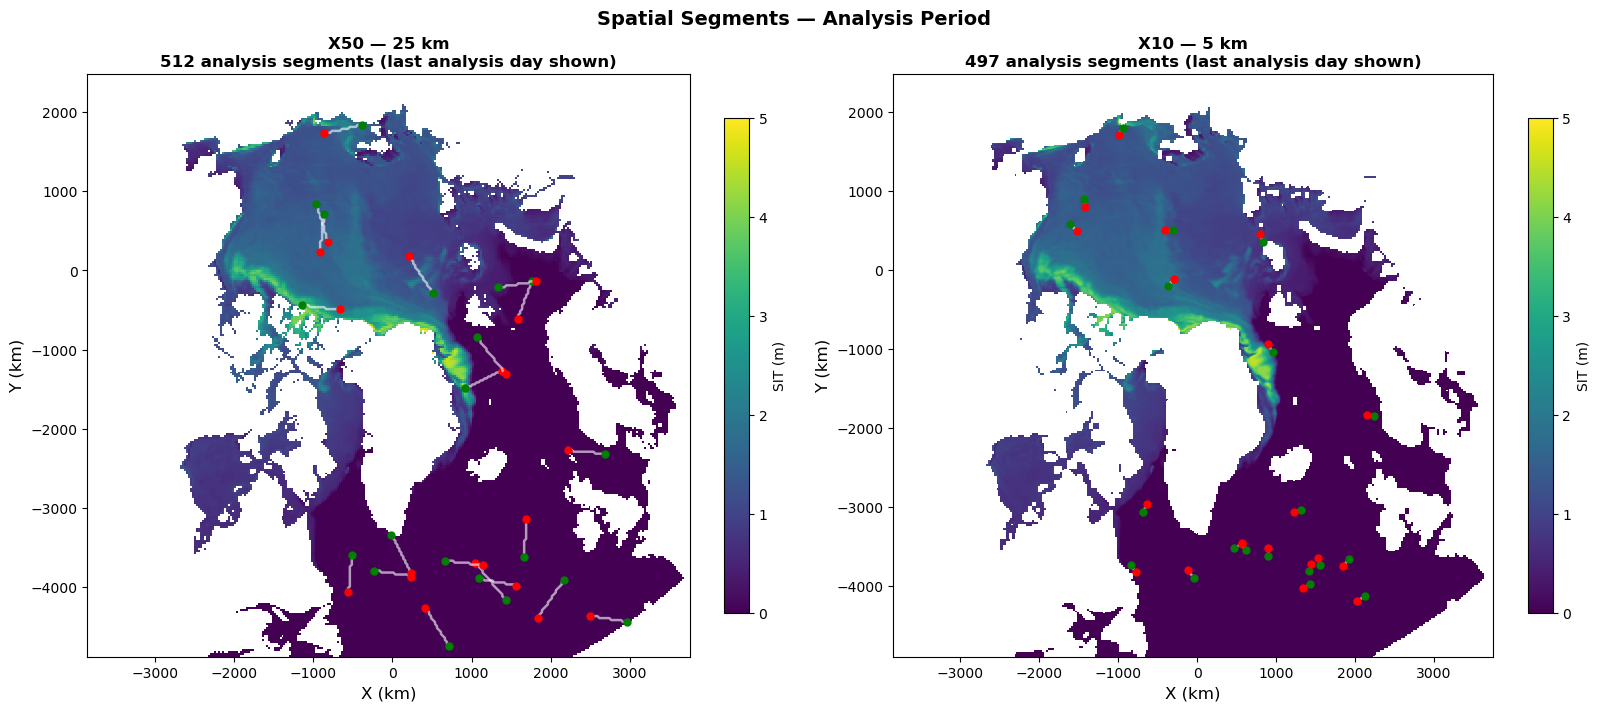


✓ Saved to /data/users/maxb/cristal_cit_segments.png


In [9]:
# ── Visualise sampled segments on the last analysis day ───────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 7), constrained_layout=True)

for ax, key in zip(axes, ['x50', 'x10']):
    d = cristal_data[key]
    xc_km = km(d['xc'])
    yc_km = km(d['yc'])
    X, Y = np.meshgrid(xc_km, yc_km, indexing='xy')

    im = ax.pcolormesh(X, Y, d['models_analysis'][-1], cmap='viridis',
                       vmin=0, vmax=5, shading='nearest', rasterized=True)
    ax.set_aspect('equal')
    ax.set_xlabel('X (km)', fontsize=12)
    ax.set_ylabel('Y (km)', fontsize=12)

    seg = segments_data.get(key)
    if seg is not None:
        n_plot = min(20, seg['count'])
        for i in range(n_plot):
            xs = np.array(seg['x'][i]) / 1000 if np.nanmax(np.abs(seg['x'][i])) > 10_000 else seg['x'][i]
            ys = np.array(seg['y'][i]) / 1000 if np.nanmax(np.abs(seg['y'][i])) > 10_000 else seg['y'][i]
            ax.plot(xs, ys, 'w-', lw=1.8, alpha=0.6)
            ax.plot(xs[0],  ys[0],  'go', ms=5)
            ax.plot(xs[-1], ys[-1], 'ro', ms=5)
        n_count = seg['count']
    else:
        n_count = 0

    ax.set_title(f'{key.upper()} — {d["resolution_km"]:.0f} km\n'
                 f'{n_count} analysis segments (last analysis day shown)',
                 fontsize=12, fontweight='bold')
    plt.colorbar(im, ax=ax, label='SIT (m)', shrink=0.85)

fig.suptitle('Spatial Segments — Analysis Period', fontsize=14, fontweight='bold')
out = '/data/users/maxb/cristal_cit_segments.png'
plt.savefig(out, dpi=130, bbox_inches='tight')
plt.show()
print(f"\n✓ Saved to {out}")


In [10]:
# ── Compute PSD — analysis period ─────────────────────────────────────────────
import os

print("\n" + "=" * 80)
print("COMPUTING SPECTRAL SCORES — ANALYSIS PERIOD")
print("=" * 80)

spectral_output_dir = '/data/users/maxb/cristal_cit_spectral'
os.makedirs(spectral_output_dir, exist_ok=True)

spectral_results_analysis = {}

for key, data in spectral_data.items():
    out_nc = os.path.join(spectral_output_dir, f'psd_analysis_{key}.nc')
    p = SEGMENT_PARAMS[key]
    print(f"\n{key} — {data['resolution_km']:.0f} km")
    try:
        compute_spectral_scores_cartesian(
            time=data['time'], x=data['x'], y=data['y'],
            obs=data['obs'], rec=data['rec'],
            mode='spatial', delta=data['dx'],
            output_filename=out_nc,
            min_dist=p['min_dist'], max_dist=p['max_dist'],
            dx=data['dx'], dy=data['dy'],
        )
        spectral_results_analysis[key] = out_nc
        print(f"  ✓ Saved → {out_nc}")
    except Exception as e:
        print(f"  ✗ ERROR: {e}")
        spectral_results_analysis[key] = None

print("\n" + "=" * 80)
print("DONE")
print("=" * 80)



COMPUTING SPECTRAL SCORES — ANALYSIS PERIOD

x50 — 25 km


INFO:root:Spectral scores saved to /data/users/maxb/cristal_cit_spectral/psd_analysis_x50.nc
INFO:root:Spectral scores saved to /data/users/maxb/cristal_cit_spectral/psd_analysis_x10.nc
INFO:root:Spectral scores saved to /data/users/maxb/cristal_cit_spectral/psd_analysis_x10.nc


  ✓ Saved → /data/users/maxb/cristal_cit_spectral/psd_analysis_x50.nc

x10 — 5 km
  ✓ Saved → /data/users/maxb/cristal_cit_spectral/psd_analysis_x10.nc

DONE


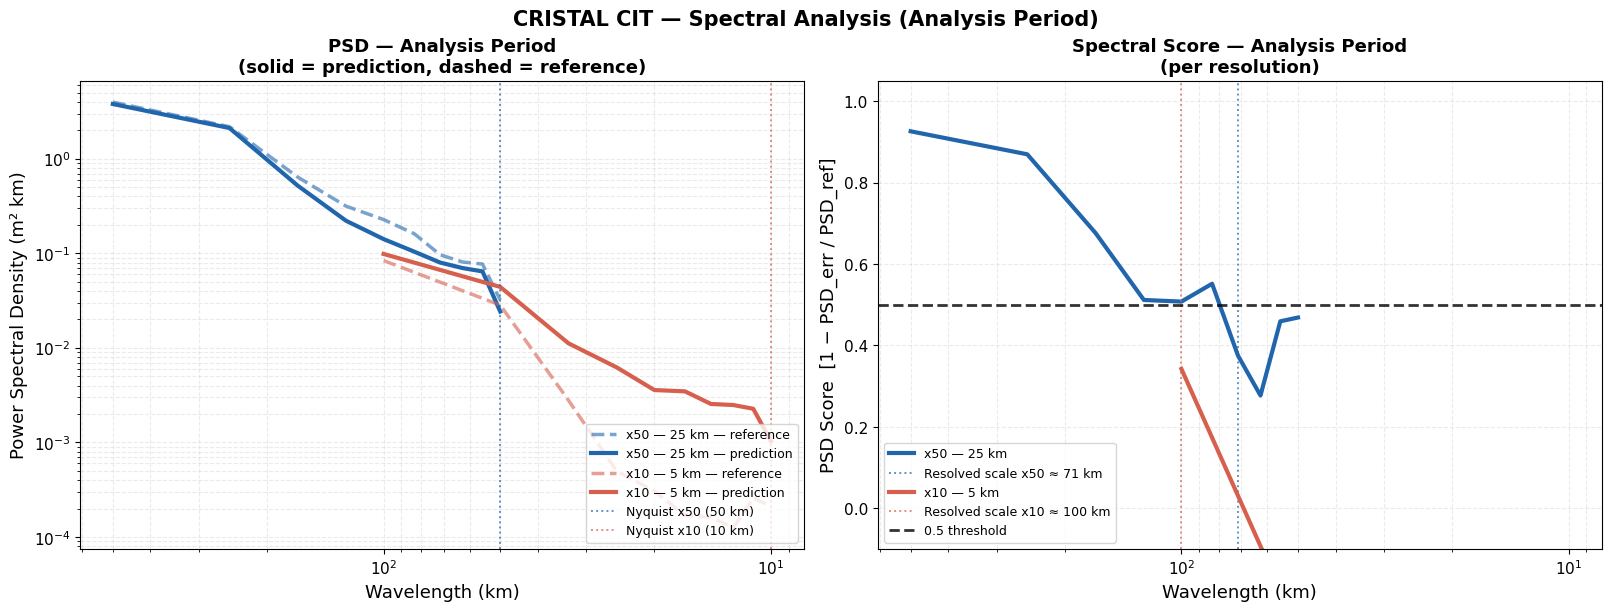


✓ Saved to /data/users/maxb/cristal_cit_psd_analysis.png


In [11]:
# ── Pretty PSD plots — analysis period, both resolutions ──────────────────────
# Style dictionary per resolution
RES_STYLE = {
    'x50': dict(color='#2166AC', lw=3.0,   ls='-',  marker='o', ms=6,  label='x50 — 25 km'),
    'x10': dict(color='#D6604D', lw=3.0,   ls='-',  marker='s', ms=6,  label='x10 — 5 km'),
}
REF_ALPHA  = 0.45
SCORE_LTHRES = 0.5

fig, axes = plt.subplots(1, 2, figsize=(16, 6), constrained_layout=True)
ax_psd, ax_score = axes

# ─── PSD ──────────────────────────────────────────────────────────────────────
for key, nc in spectral_results_analysis.items():
    if nc is None:
        continue
    ds_psd = xr.open_dataset(nc)
    wl = 1.0 / ds_psd.wavenumber
    st = RES_STYLE[key]

    # Reference (models_SIT)
    ax_psd.loglog(wl, ds_psd.psd_ref, color=st['color'], lw=st['lw'] - 0.5,
                  ls='--', alpha=0.6, label=f"{st['label']} — reference")
    # Reconstruction (pred_SIT)
    ax_psd.loglog(wl, ds_psd.psd_study, color=st['color'], lw=st['lw'],
                  ls='-', label=f"{st['label']} — prediction")
    ds_psd.close()

# Resolution separator lines
for key in spectral_results_analysis:
    nyq = 2.0 * cristal_data[key]['resolution_km']
    ax_psd.axvline(nyq, color=RES_STYLE[key]['color'], lw=1.4, ls=':',
                   alpha=0.7, label=f"Nyquist {key} ({nyq:.0f} km)")

ax_psd.set_xlabel('Wavelength (km)', fontsize=13)
ax_psd.set_ylabel('Power Spectral Density (m² km)', fontsize=13)
ax_psd.set_title('PSD — Analysis Period\n(solid = prediction, dashed = reference)',
                 fontsize=13, fontweight='bold')
ax_psd.legend(fontsize=9, loc='lower right')
ax_psd.grid(True, which='both', alpha=0.25, ls='--')
ax_psd.invert_xaxis()
ax_psd.tick_params(labelsize=11)

# ─── PSD Score ────────────────────────────────────────────────────────────────
for key, nc in spectral_results_analysis.items():
    if nc is None:
        continue
    ds_psd = xr.open_dataset(nc)
    wl = 1.0 / ds_psd.wavenumber
    score = 1.0 - ds_psd.psd_diff / ds_psd.psd_ref
    st = RES_STYLE[key]

    ax_score.semilogx(wl, score, color=st['color'], lw=st['lw'],
                      ls=st['ls'], label=st['label'])

    # Resolved scale marker
    crossing = np.where(score.values < SCORE_LTHRES)[0]
    if len(crossing):
        rs = float(wl.values[crossing[0]])
        ax_score.axvline(rs, color=st['color'], lw=1.4, ls=':', alpha=0.7,
                         label=f"Resolved scale {key} ≈ {rs:.0f} km")
    ds_psd.close()

ax_score.axhline(SCORE_LTHRES, color='black', lw=2.0, ls='--', alpha=0.8, label='0.5 threshold')
ax_score.set_xlabel('Wavelength (km)', fontsize=13)
ax_score.set_ylabel('PSD Score  [1 − PSD_err / PSD_ref]', fontsize=13)
ax_score.set_title('Spectral Score — Analysis Period\n(per resolution)',
                   fontsize=13, fontweight='bold')
ax_score.legend(fontsize=9, loc='lower left')
ax_score.grid(True, which='both', alpha=0.25, ls='--')
ax_score.invert_xaxis()
ax_score.set_ylim([-0.1, 1.05])
ax_score.tick_params(labelsize=11)

# Decorative vertical separator between plots
fig.suptitle('CRISTAL CIT — Spectral Analysis (Analysis Period)', fontsize=15, fontweight='bold')
out = '/data/users/maxb/cristal_cit_psd_analysis.png'
plt.savefig(out, dpi=150, bbox_inches='tight')
plt.show()
print(f"\n✓ Saved to {out}")


In [12]:
# ── Forecast evaluation — PSD scores per lead time ────────────────────────────
# For each lead time lt ∈ {0, 1, 2} and each resolution:
#   - Reference  : models_SIT[n_analysis + lt]
#   - Persistence: models_SIT[n_analysis - 1]   (last analysis day, constant)
#   - Forecast   : pred_SIT[n_analysis + lt]
#
# We wrap each 2-D field in a pseudo-time axis (size=1) to reuse the Welch machinery.

print("=" * 80)
print("FORECAST EVALUATION — PSD SCORES PER LEAD TIME")
print("=" * 80)

LEAD_TIMES  = [0, 1, 2]
FIELD_NAMES = ['reference', 'persistence', 'forecast']

# Store all PSD nc paths: psd_fc[key][lt][field_name]
psd_fc = {key: {lt: {} for lt in LEAD_TIMES} for key in ['x50', 'x10']}

for key in ['x50', 'x10']:
    d  = cristal_data[key]
    p  = SEGMENT_PARAMS[key]
    print(f"\n{'─'*60}")
    print(f"Resolution {key} — {d['resolution_km']:.0f} km")

    for lt in LEAD_TIMES:
        ref_2d   = d['models_forecast'][lt]          # (yc, xc)
        pers_2d  = d['persistence'][lt]              # (yc, xc)
        pred_2d  = d['pred_forecast'][lt]            # (yc, xc)

        # Wrap in pseudo-time axis
        ref_3d   = ref_2d[np.newaxis]
        pers_3d  = pers_2d[np.newaxis]
        pred_3d  = pred_2d[np.newaxis]

        for field_name, rec_3d in [('persistence', pers_3d), ('forecast', pred_3d)]:
            out_nc = os.path.join(
                spectral_output_dir, f'psd_fc_{key}_lt{lt}_{field_name}.nc'
            )
            try:
                compute_spectral_scores_cartesian(
                    time=np.array([0]), x=d['xc'], y=d['yc'],
                    obs=ref_3d, rec=rec_3d,
                    mode='spatial', delta=d['dx'],
                    output_filename=out_nc,
                    min_dist=p['min_dist'], max_dist=p['max_dist'],
                    dx=d['dx'], dy=d['dy'],
                )
                psd_fc[key][lt][field_name] = out_nc
                print(f"  ✓ lt={lt} {field_name} → {os.path.basename(out_nc)}")
            except Exception as e:
                print(f"  ✗ lt={lt} {field_name}: {e}")
                psd_fc[key][lt][field_name] = None

print("\n" + "=" * 80)
print("DONE")
print("=" * 80)


INFO:root:Spectral scores saved to /data/users/maxb/cristal_cit_spectral/psd_fc_x50_lt0_persistence.nc


FORECAST EVALUATION — PSD SCORES PER LEAD TIME

────────────────────────────────────────────────────────────
Resolution x50 — 25 km
  ✓ lt=0 persistence → psd_fc_x50_lt0_persistence.nc


INFO:root:Spectral scores saved to /data/users/maxb/cristal_cit_spectral/psd_fc_x50_lt0_forecast.nc


  ✓ lt=0 forecast → psd_fc_x50_lt0_forecast.nc


INFO:root:Spectral scores saved to /data/users/maxb/cristal_cit_spectral/psd_fc_x50_lt1_persistence.nc


...

  ✓ lt=1 forecast → psd_fc_x10_lt1_forecast.nc


INFO:root:Spectral scores saved to /data/users/maxb/cristal_cit_spectral/psd_fc_x10_lt2_persistence.nc


  ✓ lt=2 persistence → psd_fc_x10_lt2_persistence.nc


INFO:root:Spectral scores saved to /data/users/maxb/cristal_cit_spectral/psd_fc_x10_lt2_forecast.nc


  ✓ lt=2 forecast → psd_fc_x10_lt2_forecast.nc

DONE


## 5. Forecast Spectral Score Plots — Per Lead Time & Resolution


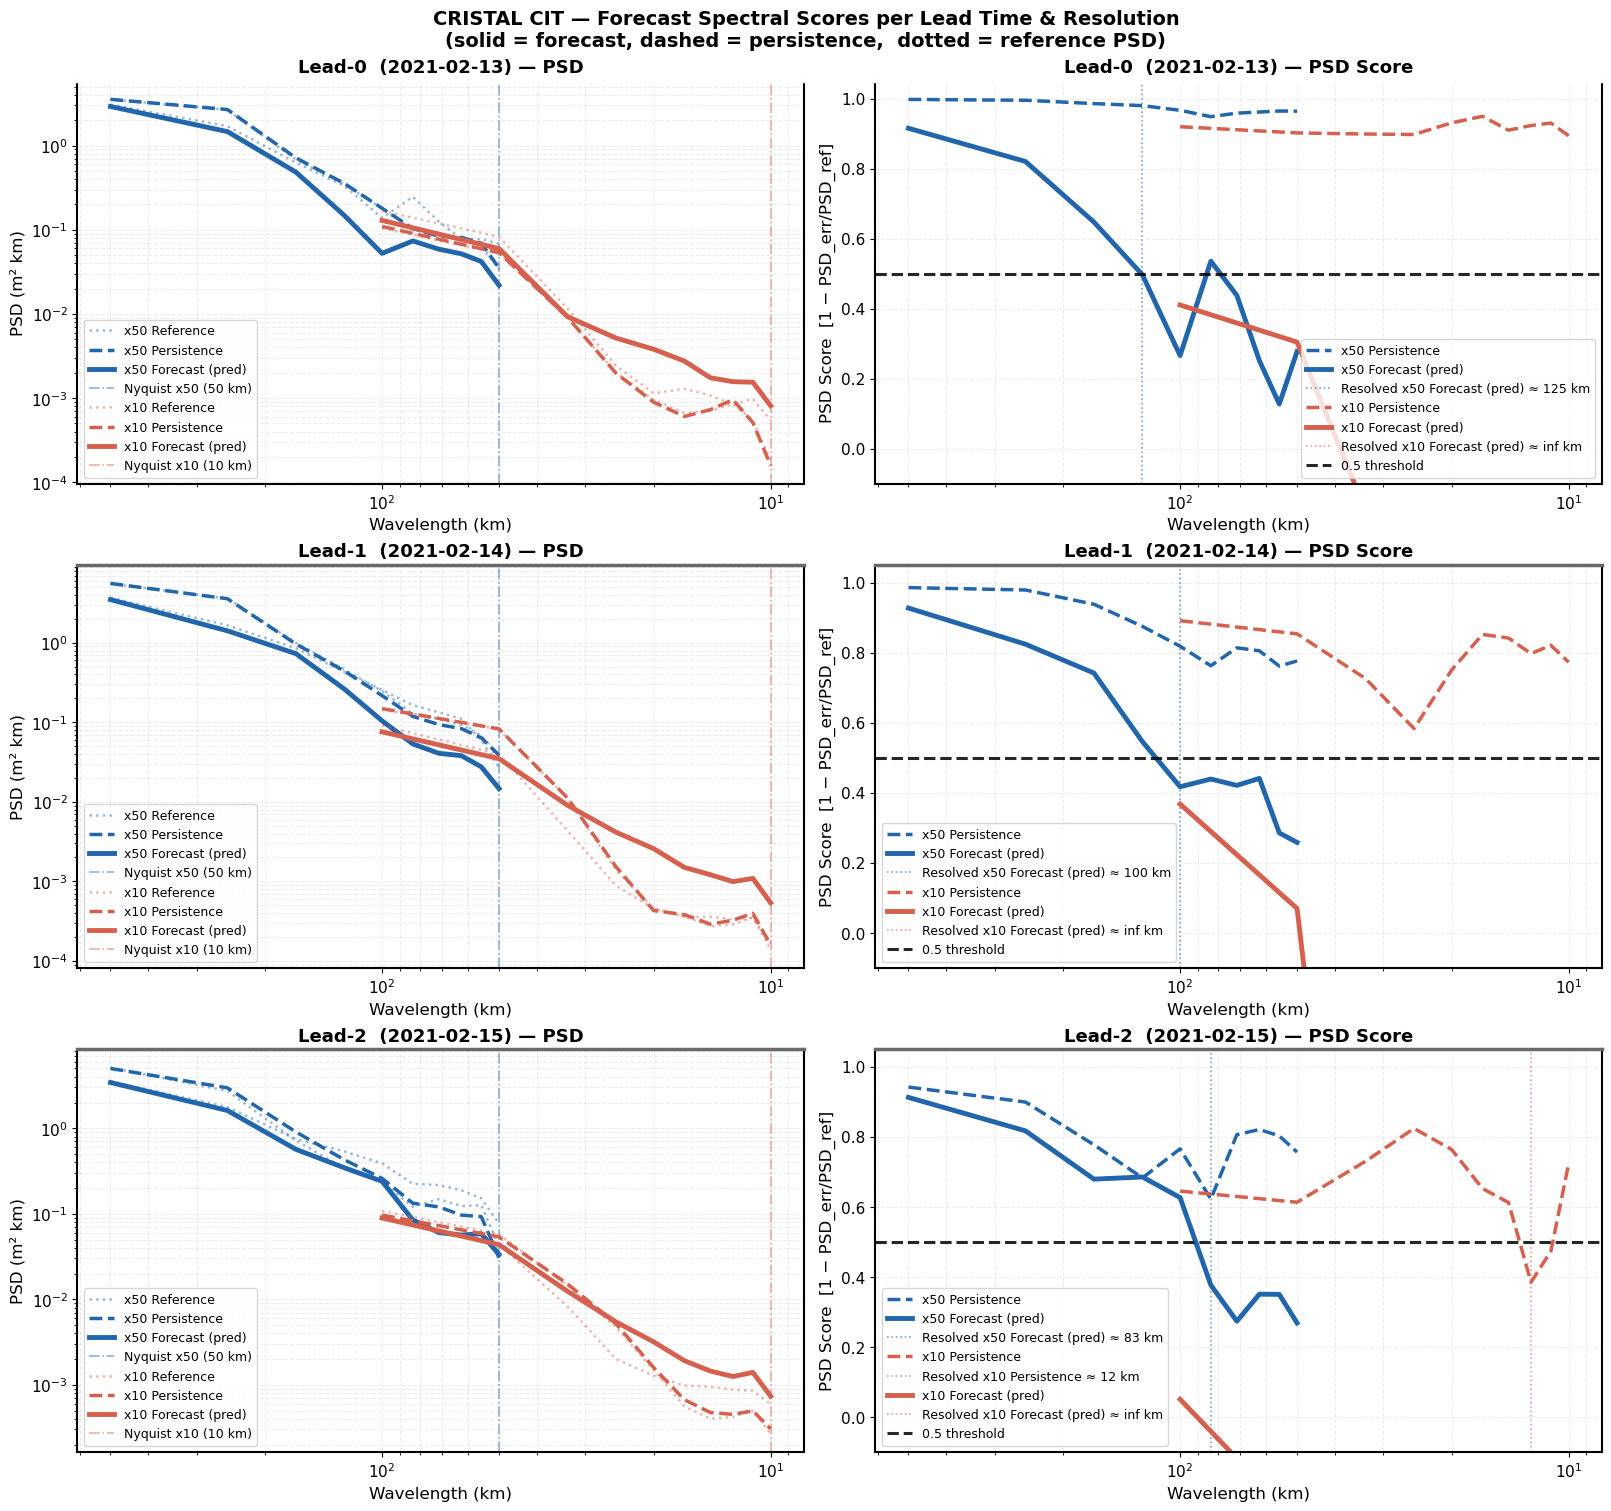


✓ Saved to /data/users/maxb/cristal_cit_psd_forecast_per_leadtime.png


In [13]:
# ── Pretty PSD Score plots — per lead time, both resolutions ──────────────────
# Layout: 1 row per lead time, 2 panels per row (PSD | Score)

# Style per (resolution, field) pair
FIELD_STYLE = {
    # (key,       field)          color         lw    ls      marker
    ('x50', 'persistence'): dict(color='#2166AC', lw=2.5, ls='--',  marker='o', ms=5),
    ('x50', 'forecast')   : dict(color='#2166AC', lw=3.5, ls='-',   marker='o', ms=7),
    ('x10', 'persistence'): dict(color='#D6604D', lw=2.5, ls='--',  marker='s', ms=5),
    ('x10', 'forecast')   : dict(color='#D6604D', lw=3.5, ls='-',   marker='s', ms=7),
}
FIELD_LABEL = {
    'persistence': 'Persistence',
    'forecast':    'Forecast (pred)',
}
SCORE_THRESH = 0.5

n_lt = len(LEAD_TIMES)
fig, axes = plt.subplots(n_lt, 2, figsize=(16, 5 * n_lt), constrained_layout=True)
if n_lt == 1:
    axes = axes[np.newaxis, :]

for row, lt in enumerate(LEAD_TIMES):
    ax_psd, ax_score = axes[row]

    # Title annotation for the row
    fc_date_x50 = cristal_data['x50']['times_forecast'][lt].astype('datetime64[D]')
    ax_psd.set_title(f'Lead-{lt}  ({fc_date_x50}) — PSD', fontsize=13, fontweight='bold')
    ax_score.set_title(f'Lead-{lt}  ({fc_date_x50}) — PSD Score', fontsize=13, fontweight='bold')

    for key in ['x50', 'x10']:
        d = cristal_data[key]

        for field in ['persistence', 'forecast']:
            nc = psd_fc[key][lt].get(field)
            if nc is None:
                continue
            ds_psd = xr.open_dataset(nc)
            wl     = 1.0 / ds_psd.wavenumber
            score  = 1.0 - ds_psd.psd_diff / ds_psd.psd_ref
            st     = FIELD_STYLE[(key, field)]
            lbl    = f"{key} {FIELD_LABEL[field]}"

            ax_psd.loglog(wl, ds_psd.psd_ref,   color=st['color'], lw=1.8,
                          ls=':', alpha=0.45,
                          label=f"{key} Reference" if field == 'persistence' else '_nolegend_')
            ax_psd.loglog(wl, ds_psd.psd_study, color=st['color'], lw=st['lw'],
                          ls=st['ls'], label=lbl)
            ax_score.semilogx(wl, score, color=st['color'], lw=st['lw'],
                              ls=st['ls'], label=lbl)

            # Resolved scale marker on score plot
            valid_mask = np.isfinite(score.values)
            if valid_mask.any():
                crossing = np.where(score.values[valid_mask] < SCORE_THRESH)[0]
                wl_valid = wl.values[valid_mask]
                if len(crossing):
                    rs = wl_valid[crossing[0]]
                    ax_score.axvline(rs, color=st['color'], lw=1.2,
                                     ls=':', alpha=0.6,
                                     label=f"Resolved {key} {FIELD_LABEL[field]} ≈ {rs:.0f} km")
            ds_psd.close()

        # Nyquist lines on PSD
        nyq = 2.0 * d['resolution_km']
        ax_psd.axvline(nyq, color=RES_STYLE[key]['color'], lw=1.2, ls='-.',
                       alpha=0.5, label=f"Nyquist {key} ({nyq:.0f} km)")

    # 0.5 threshold on score panel
    ax_score.axhline(SCORE_THRESH, color='black', lw=2.2, ls='--', alpha=0.85,
                     label='0.5 threshold')

    # Shared formatting
    for ax in (ax_psd, ax_score):
        ax.invert_xaxis()
        ax.grid(True, which='both', alpha=0.22, ls='--')
        ax.legend(fontsize=9, loc='best')
        ax.tick_params(labelsize=11)
    ax_psd.set_xlabel('Wavelength (km)', fontsize=12)
    ax_psd.set_ylabel('PSD (m² km)', fontsize=12)
    ax_score.set_xlabel('Wavelength (km)', fontsize=12)
    ax_score.set_ylabel('PSD Score  [1 − PSD_err/PSD_ref]', fontsize=12)
    ax_score.set_ylim([-0.1, 1.05])

    # Visual separator between rows (thick top spine)
    for ax in (ax_psd, ax_score):
        for spine in ax.spines.values():
            spine.set_linewidth(1.5)
        ax.spines['top'].set_linewidth(2.5)
        ax.spines['top'].set_color('dimgray' if row > 0 else 'white')

fig.suptitle('CRISTAL CIT — Forecast Spectral Scores per Lead Time & Resolution\n'
             '(solid = forecast, dashed = persistence,  dotted = reference PSD)',
             fontsize=14, fontweight='bold')

out = '/data/users/maxb/cristal_cit_psd_forecast_per_leadtime.png'
plt.savefig(out, dpi=150, bbox_inches='tight')
plt.show()
print(f"\n✓ Saved to {out}")


RESOLVED SCALES SUMMARY
resolution   period       field lead_time  resolved_scale_km  grid_km  ratio
       x50 analysis  prediction         -               71.4     25.0    2.9
       x10 analysis  prediction         -              100.0      5.0   20.0
       x50 forecast persistence         0                NaN     25.0    NaN
       x50 forecast    forecast         0              125.0     25.0    5.0
       x50 forecast persistence         1                NaN     25.0    NaN
       x50 forecast    forecast         1              100.0     25.0    4.0
       x50 forecast persistence         2                NaN     25.0    NaN
       x50 forecast    forecast         2               83.3     25.0    3.3
       x10 forecast persistence         0                NaN      5.0    NaN
       x10 forecast    forecast         0                inf      5.0    NaN
       x10 forecast persistence         1                NaN      5.0    NaN
       x10 forecast    forecast         1           

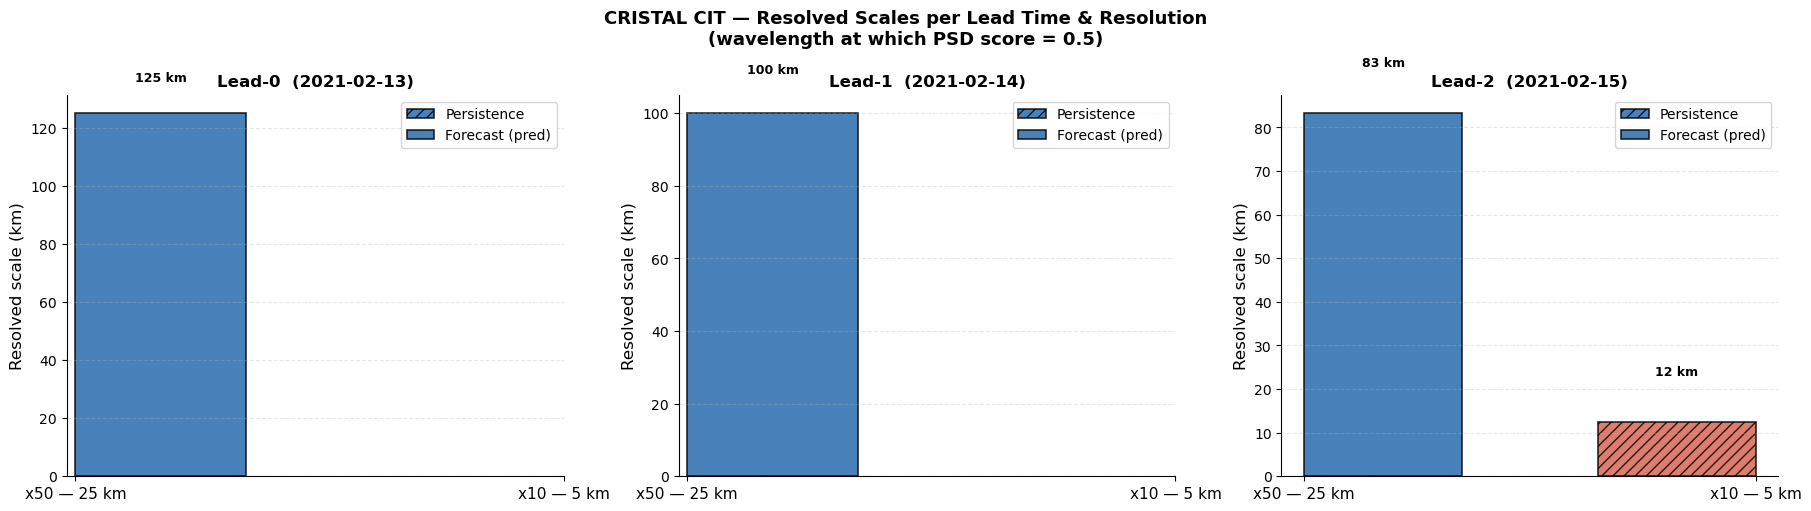


✓ Saved to /data/users/maxb/cristal_cit_resolved_scales.png


In [14]:
# ── Resolved Scales Summary ────────────────────────────────────────────────────
# Collect resolved scales (0.5 PSD-score crossing) per resolution, field, lead time

print("=" * 80)
print("RESOLVED SCALES SUMMARY")
print("=" * 80)

import pandas as pd

rows = []

# Analysis period
for key, nc in spectral_results_analysis.items():
    if nc is None:
        continue
    ds_psd = xr.open_dataset(nc)
    wl     = 1.0 / ds_psd.wavenumber
    score  = (1.0 - ds_psd.psd_diff / ds_psd.psd_ref).values
    mask   = np.isfinite(score)
    c      = np.where(score[mask] < 0.5)[0]
    rs     = wl.values[mask][c[0]] if len(c) else np.nan
    rows.append({'resolution': key, 'period': 'analysis', 'field': 'prediction',
                 'lead_time': '-', 'resolved_scale_km': round(rs, 1),
                 'grid_km': cristal_data[key]['resolution_km'],
                 'ratio': round(rs / cristal_data[key]['resolution_km'], 1) if np.isfinite(rs) else np.nan})
    ds_psd.close()

# Forecast period
for key in ['x50', 'x10']:
    for lt in LEAD_TIMES:
        for field in ['persistence', 'forecast']:
            nc = psd_fc[key][lt].get(field)
            if nc is None:
                continue
            ds_psd = xr.open_dataset(nc)
            wl     = 1.0 / ds_psd.wavenumber
            score  = (1.0 - ds_psd.psd_diff / ds_psd.psd_ref).values
            mask   = np.isfinite(score)
            c      = np.where(score[mask] < 0.5)[0]
            rs     = wl.values[mask][c[0]] if len(c) else np.nan
            rows.append({'resolution': key, 'period': 'forecast',
                         'field': field, 'lead_time': lt,
                         'resolved_scale_km': round(rs, 1),
                         'grid_km': cristal_data[key]['resolution_km'],
                         'ratio': round(rs / cristal_data[key]['resolution_km'], 1) if np.isfinite(rs) else np.nan})
            ds_psd.close()

df_scales = pd.DataFrame(rows)
print(df_scales.to_string(index=False))

# Bar-chart summary
fig, axes = plt.subplots(1, N_FORECAST, figsize=(6 * N_FORECAST, 5), constrained_layout=True)
if N_FORECAST == 1:
    axes = [axes]

BAR_COLORS = {'x50': '#2166AC', 'x10': '#D6604D'}
BAR_HATCHES = {'persistence': '///', 'forecast': ''}

for lt, ax in zip(LEAD_TIMES, axes):
    sub = df_scales[(df_scales['period'] == 'forecast') & (df_scales['lead_time'] == lt)]
    x_pos = np.arange(len(['x50', 'x10']))
    width = 0.35
    for fi, field in enumerate(['persistence', 'forecast']):
        vals = [sub[(sub['resolution'] == k) & (sub['field'] == field)]['resolved_scale_km'].values
                for k in ['x50', 'x10']]
        vals = [v[0] if len(v) else np.nan for v in vals]
        bars = ax.bar(x_pos + fi * width - width / 2, vals, width,
                      label=FIELD_LABEL[field],
                      color=[BAR_COLORS[k] for k in ['x50', 'x10']],
                      hatch=BAR_HATCHES[field], alpha=0.82, edgecolor='black', lw=1.2)
        for bar, v in zip(bars, vals):
            if np.isfinite(v):
                ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 10,
                        f'{v:.0f} km', ha='center', va='bottom', fontsize=9, fontweight='bold')
    ax.set_xticks(x_pos)
    ax.set_xticklabels(['x50 — 25 km', 'x10 — 5 km'], fontsize=11)
    ax.set_ylabel('Resolved scale (km)', fontsize=12)
    ax.set_title(f'Lead-{lt}  ({cristal_data["x50"]["times_forecast"][lt].astype("datetime64[D]")})',
                 fontsize=12, fontweight='bold')
    ax.legend(fontsize=10)
    ax.grid(axis='y', alpha=0.3, ls='--')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

fig.suptitle('CRISTAL CIT — Resolved Scales per Lead Time & Resolution\n'
             '(wavelength at which PSD score = 0.5)',
             fontsize=13, fontweight='bold')
out = '/data/users/maxb/cristal_cit_resolved_scales.png'
plt.savefig(out, dpi=150, bbox_inches='tight')
plt.show()
print(f"\n✓ Saved to {out}")
